# Below we import packages we may need

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap
import statsmodels.api as sm
import random
from scipy import stats
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
from matplotlib.font_manager import FontProperties
import matplotlib.lines as mlines
from statsmodels.formula.api import ols
import itertools
import keyword

<a class="anchor" id="Data"></a>
Below we import the data.

In [10]:
annotated_mz_data = pd.read_csv("C:/PhD rotation 1/New Analysis Annotated mz/annotated_mz_only_post_processed_maplet_data.csv", index_col = 0)
annotated_mz_data

,341.3045359,688.1566289,480.3106071,452.2779431,137.0476093,266.1729689,275.0078481,551.3492125,343.1310698,988.5106837,...,497.2887359,522.352938,517.3715465,519.2700787,268.1195442,361.1697371,Group,Organism,date_measured,batch_measured
CARB_220421_0001,0.235379,1.255321,-0.743633,-0.451378,-0.735257,0.299373,0.487887,-0.986562,0.330911,-0.600910,...,-0.050445,-0.445337,0.862473,0.225198,0.195512,0.410076,CRE,Escherichia coli,apr21,apr21
CARB_220421_0002,0.302080,0.660567,-0.628927,0.204759,-1.734406,-0.344743,-1.674753,-0.423016,0.102218,0.417236,...,0.794827,0.220338,0.373972,0.282055,0.333397,-0.125571,CRE,Enterobacter cloacae,apr21,apr21
CARB_220421_0003,-1.162677,0.023574,-0.819531,-0.349414,-1.408124,0.422816,-0.424128,-0.797650,-1.337279,-0.055619,...,0.592715,-0.186625,1.203281,0.514182,0.197211,0.384633,CRE,Klebsiella pneumoniae,apr21,apr21
CARB_220421_0004,-0.081062,0.785580,-2.157372,-1.714977,-1.424713,-0.197547,-0.240823,-0.608056,0.326369,0.888960,...,-0.041695,-0.431125,1.475143,0.326514,0.015376,-0.135694,CRE,Klebsiella pneumoniae,apr21,apr21
CARB_220421_0005,0.158468,1.086008,-2.315403,-1.202203,-0.033887,0.055588,1.091046,-2.002347,0.594032,0.697582,...,0.019417,-0.877367,1.926909,-0.133431,-0.162075,-0.317338,CRE,Klebsiella pneumoniae,apr21,apr21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CARB_220427_1065,-0.586130,-1.675135,0.457437,1.047182,1.004619,-0.322823,0.438064,-0.907827,0.606538,-0.640901,...,-0.132483,-0.271630,-0.609894,-0.119328,-0.169864,0.168971,CRE,Klebsiella pneumoniae,apr27,apr25_27
CARB_220427_1090,-1.744303,-0.207907,1.716507,1.087543,1.066645,0.438027,-0.342687,0.617194,-0.472748,-2.520532,...,0.446995,-0.484318,-0.254279,0.312930,0.264202,1.229598,CSE,Klebsiella pneumoniae,apr27,apr25_27
CARB_220427_1100,0.825350,1.079930,-0.816730,-0.876715,-1.749845,0.950413,-2.605379,0.890565,-2.061110,0.606860,...,-0.768276,-0.035163,0.302748,-0.694387,-0.524554,-0.034586,CSE,Escherichia coli,apr27,apr25_27
CARB_220427_1980,-1.438140,1.118891,0.855119,0.799500,-0.651932,-0.974634,0.048687,1.707099,0.814822,0.514977,...,0.688815,0.991651,1.294649,0.443743,0.465036,-1.296725,CRE,Escherichia coli,apr27,apr25_27


Below we look at a random sample of 20 metabolite distributions.

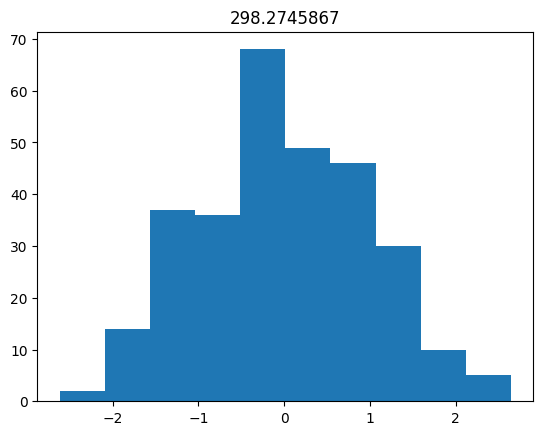

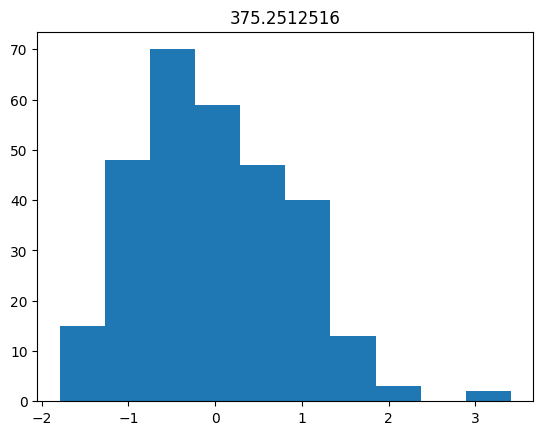

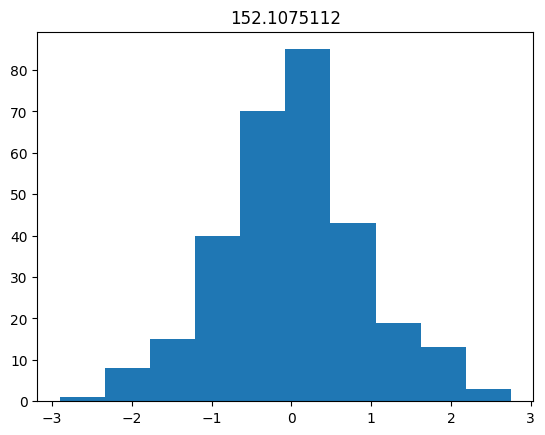

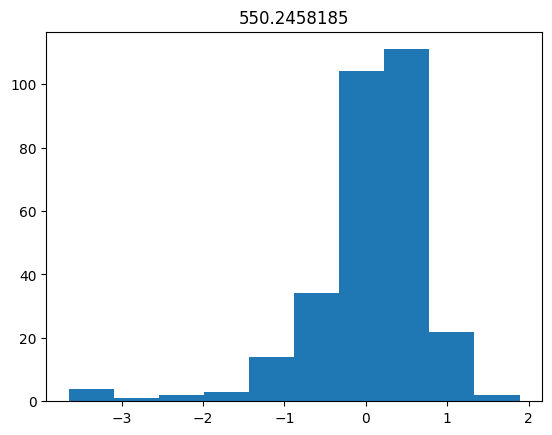

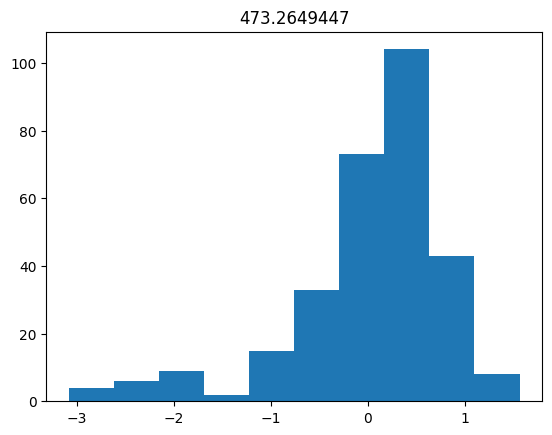

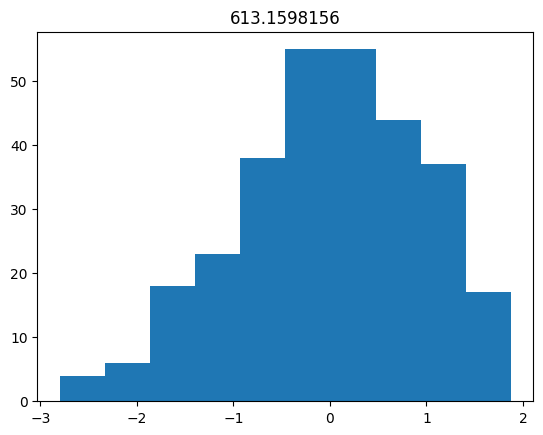

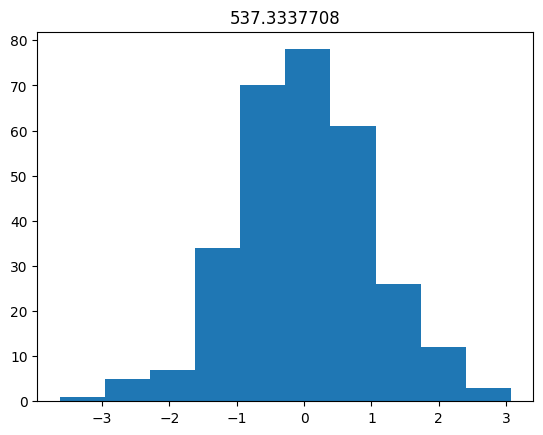

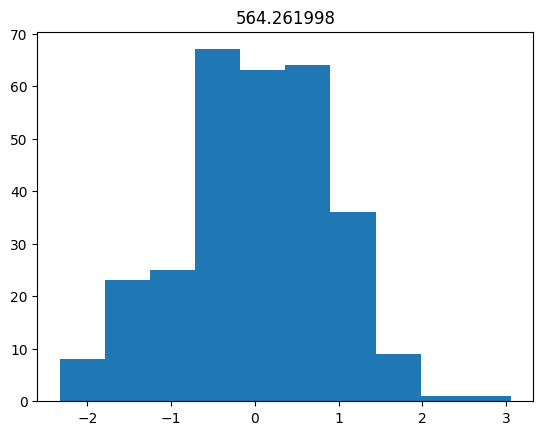

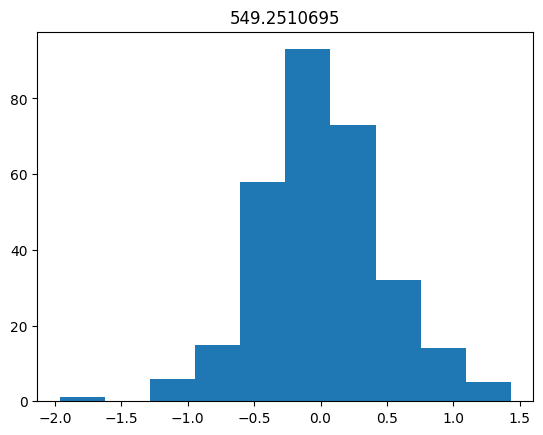

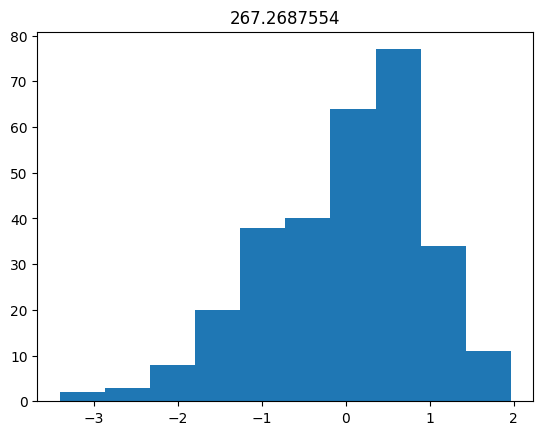

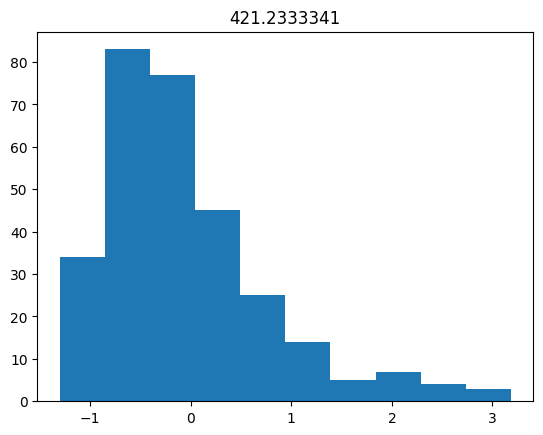

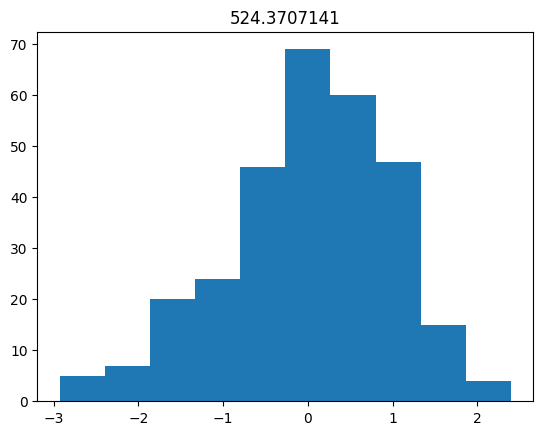

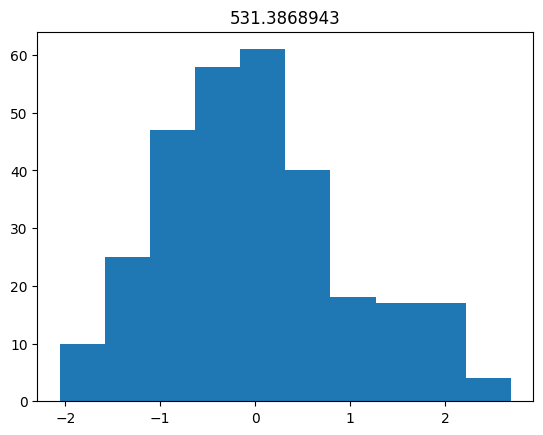

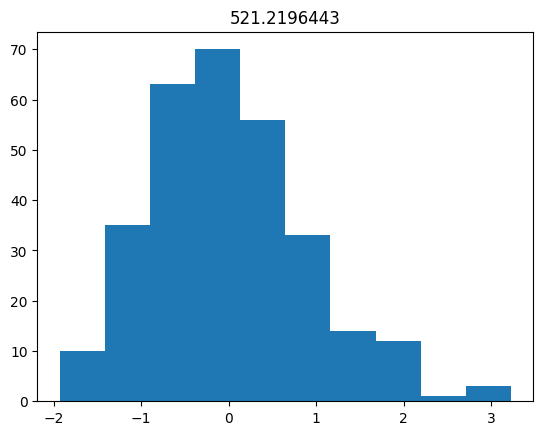

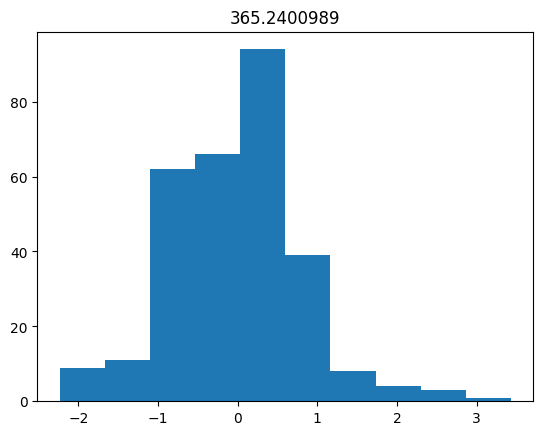

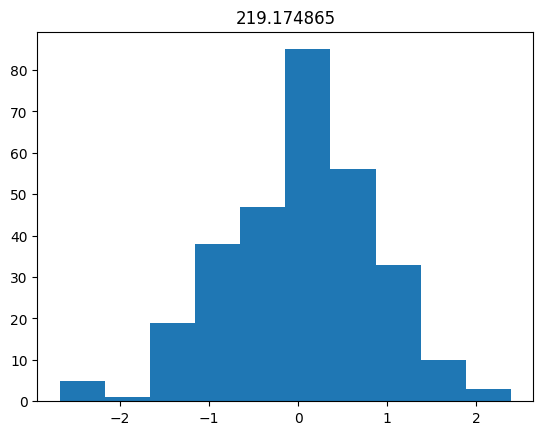

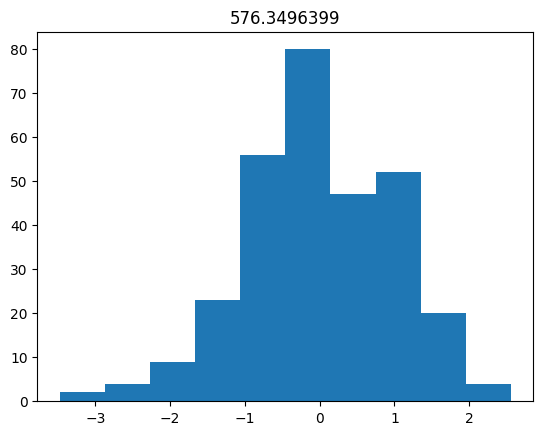

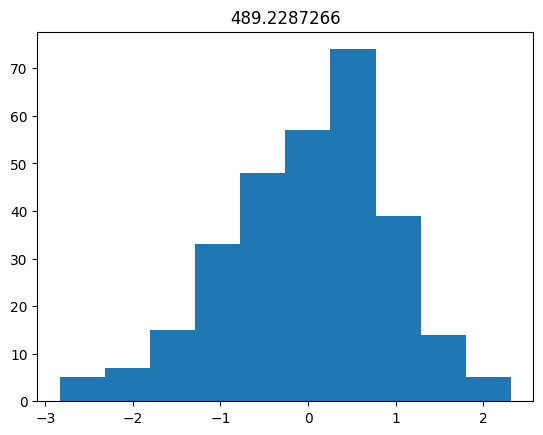

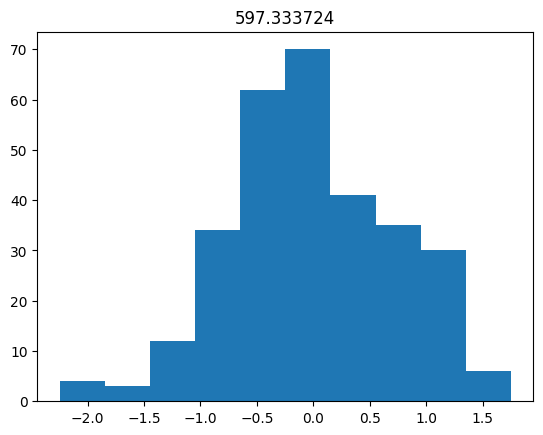

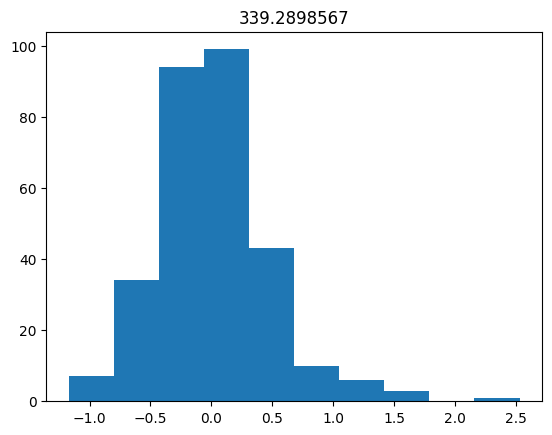

In [11]:
for met in annotated_mz_data.columns.to_series().sample(n=20, random_state=100):  # random_state for reproducibility
    plt.hist(annotated_mz_data[met])
    plt.title(met)
    plt.show()

Below we create a umap.

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


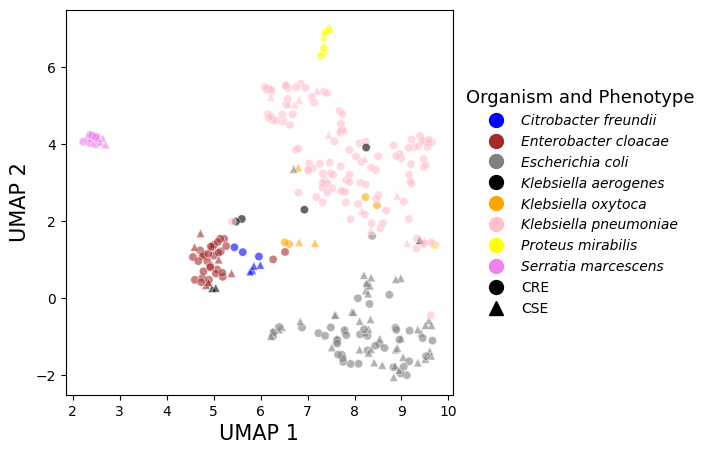

In [ ]:
# Perform UMAP reduction
reducer = umap.UMAP(random_state=100)
embedding = reducer.fit_transform(annotated_mz_data.drop(columns=['Group', 'Organism', 'date_measured', 'batch_measured']))

# Create DataFrame with embedding and metadata
embedding_df = pd.concat([pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2']), 
                           annotated_mz_data[['Group', 'Organism']].reset_index(drop=True)], axis=1)

# Define a custom color palette for Organism
custom_palette = {
    'Citrobacter freundii': 'blue',
    'Enterobacter cloacae': 'brown',
    'Escherichia coli': 'gray',
    'Klebsiella aerogenes': 'black',
    'Klebsiella oxytoca': 'orange',
    'Klebsiella pneumoniae': 'pink',
    'Proteus mirabilis': 'yellow',
    'Serratia marcescens': 'violet'
}

# Plot with seaborn
plt.figure(figsize=(5, 5))

# Create a scatter plot with custom markers for Group and custom palette for Organism
plot = sns.scatterplot(data=embedding_df, x='UMAP1', y='UMAP2', hue='Organism', style='Group', alpha=0.6, 
                       palette=custom_palette, markers={'CRE': 'o', 'CSE': '^'})  # 'o' for circle, '^' for triangle

# Create custom legend handles for Organism and Group
handles = []
for organism, color in custom_palette.items():
    # Color handle for Organism
    color_handle = mlines.Line2D([], [], color=color, marker='o', markersize=10, linestyle='',
                                 label=organism)
    handles.append(color_handle)

for group in embedding_df['Group'].unique():
    # Shape handle for Group
    shape_handle = mlines.Line2D([], [], color='black', marker='o' if group == 'CRE' else '^', markersize=10, linestyle='',
                                 label=group)
    handles.append(shape_handle)

# Create combined legend
legend = plt.legend(handles=handles, title='Organism and Phenotype', title_fontsize='13', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# Italicize Organism names in the legend
for text in legend.get_texts():
    if text.get_text() in custom_palette.keys():
        text.set_fontstyle('italic')
        
#plt.title('UMAP Projection Using All Metabolites', fontsize=12)
plt.xlabel('UMAP 1', fontsize = 15)
plt.ylabel('UMAP 2', fontsize = 15)
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/after_batch_correction_organism_phenotype_umap.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/after_batch_correction_organism_phenotype_umap.tiff', format='tiff', dpi=300, bbox_inches="tight")
plt.show()


Below we look at the number of CRE and CSE for every species.

In [13]:
cf_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Citrobacter freundii']
cf_data_cre = cf_data[cf_data['Group'] == 'CRE']
print(len(cf_data_cre))
cf_data_cse = cf_data[cf_data['Group'] == 'CSE']
print(len(cf_data_cse))

ec_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Enterobacter cloacae']
ec_data_cre = ec_data[ec_data['Group'] == 'CRE']
print(len(ec_data_cre))
ec_data_cse = ec_data[ec_data['Group'] == 'CSE']
print(len(ec_data_cse))

ecoli_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Escherichia coli']
ecoli_data_cre = ecoli_data[ecoli_data['Group'] == 'CRE']
print(len(ecoli_data_cre))
ecoli_data_cse = ecoli_data[ecoli_data['Group'] == 'CSE']
print(len(ecoli_data_cse))

ka_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Klebsiella aerogenes']
ka_data_cre = ka_data[ka_data['Group'] == 'CRE']
print(len(ka_data_cre))
ka_data_cse = ka_data[ka_data['Group'] == 'CSE']
print(len(ka_data_cse))

ko_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Klebsiella oxytoca']
ko_data_cre = ko_data[ko_data['Group'] == 'CRE']
print(len(ko_data_cre))
ko_data_cse = ko_data[ko_data['Group'] == 'CSE']
print(len(ko_data_cse))

kp_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Klebsiella pneumoniae']
kp_data_cre = kp_data[kp_data['Group'] == 'CRE']
print(len(kp_data_cre))
kp_data_cse = kp_data[kp_data['Group'] == 'CSE']
print(len(kp_data_cse))

pm_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Proteus mirabilis']
pm_data_cre = pm_data[pm_data['Group'] == 'CRE']
print(len(pm_data_cre))
pm_data_cse = pm_data[pm_data['Group'] == 'CSE']
print(len(pm_data_cse))

sm_data = annotated_mz_data[annotated_mz_data['Organism'] == 'Serratia marcescens']
sm_data_cre = sm_data[sm_data['Group'] == 'CRE']
print(len(sm_data_cre))
sm_data_cse = sm_data[sm_data['Group'] == 'CSE']
print(len(sm_data_cse))

3
4
31
6
42
47
4
3
4
3
114
13
4
7
8
4


# Two-way Anova to find if there are significant differences between species/Group for metabolites

In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import itertools
import keyword

# Generate a list of unique alphabetic column names
alphabet = 'abcdefghijklmnopqrstuvwxyz'
new_column_names = []

# 1-letter combinations (a-z)
new_column_names.extend(list(alphabet))

# 2-letter combinations (aa, ab, ..., zz)
new_column_names.extend([''.join(letters) for letters in itertools.product(alphabet, repeat=2)])

# 3-letter combinations (aaa, aab, ..., zzz)
new_column_names.extend([''.join(letters) for letters in itertools.product(alphabet, repeat=3)])

# Trim the list to 512 unique names
new_column_names = new_column_names[:512]

# Create a mapping from old column names to new column names
column_mapping = {old: new for old, new in zip(annotated_mz_data.iloc[:,:512].columns, new_column_names)}

# Replace the column names in the DataFrame
annotated_mz_data_alphabet_columns = annotated_mz_data.rename(columns=column_mapping)

# List of Python keywords
python_keywords = set(keyword.kwlist)

# Identify any columns that are Python keywords
problematic_columns = [col for col in annotated_mz_data_alphabet_columns.columns if col in python_keywords]

# Rename columns by appending an underscore to avoid conflicts with keywords
for col in problematic_columns:
    annotated_mz_data_alphabet_columns.rename(columns={col: f"{col}_"}, inplace=True)
    
# List of dependent variables
dependent_vars = annotated_mz_data_alphabet_columns.drop(columns = ['Group', 'Organism', 'date_measured', 'batch_measured'])

# Initialize lists to store p-values
p_values = {
    'Organism': [],
    'Group': [],
    'Interaction': []
}

# Perform two-way ANOVA for each dependent variable
for metabolite in dependent_vars:
    model = ols(f'{metabolite} ~ C(Organism) * C(Group)', data=annotated_mz_data_alphabet_columns).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # Store p-values
    p_values['Organism'].append(anova_table['PR(>F)']['C(Organism)'])
    p_values['Group'].append(anova_table['PR(>F)']['C(Group)'])
    p_values['Interaction'].append(anova_table['PR(>F)']['C(Organism):C(Group)'])

# Convert to DataFrame for easier handling
p_values_df = pd.DataFrame(p_values)

# Apply FDR correction
fdr_corrected_pvals = p_values_df.apply(lambda p: multipletests(p, method='fdr_bh')[1])

# Add index back
fdr_corrected_pvals.index = annotated_mz_data.drop(columns = ['Group', 'Organism', 'date_measured', 'batch_measured']).columns.tolist()

# Significant dataframe for all pvals
significant_fdr_corrected_pvals = fdr_corrected_pvals[(fdr_corrected_pvals < 0.05).any(axis = 1)]
# Significant dataframe for organism
significant_fdr_corrected_pvals_organism = fdr_corrected_pvals[fdr_corrected_pvals['Organism'] < 0.05]
print('Number of significant metabolites for organism: ', len(significant_fdr_corrected_pvals_organism))
# Significant dataframe for group
significant_fdr_corrected_pvals_group = fdr_corrected_pvals[fdr_corrected_pvals['Group'] < 0.05]
print('Number of significant metabolites for group: ', len(significant_fdr_corrected_pvals_group))
# Significant dataframe for interaction
significant_fdr_corrected_pvals_interaction = fdr_corrected_pvals[fdr_corrected_pvals['Interaction'] < 0.05]
print('Number of significant metabolites for interaction: ', len(significant_fdr_corrected_pvals_interaction))

# Change name of Group column to Phenotype
fdr_corrected_pvals = fdr_corrected_pvals.rename(columns = {'Group': 'Phenotype'})

# Save final dataframe
fdr_corrected_pvals.to_csv("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/two_way_anova_fdr_corrected_pvals.csv")
fdr_corrected_pvals

Number of significant metabolites for organism:  435
Number of significant metabolites for group:  63
Number of significant metabolites for interaction:  5


,Organism,Phenotype,Interaction
341.3045359,6.086991e-02,0.681665,0.823473
688.1566289,5.081901e-13,0.080825,0.392532
480.3106071,6.983308e-02,0.266160,0.407549
452.2779431,1.863964e-17,0.441508,0.884781
137.0476093,1.107977e-17,0.407920,0.754688
...,...,...,...
522.352938,1.053804e-35,0.774469,0.510940
517.3715465,4.590064e-03,0.585581,0.983840
519.2700787,3.989778e-06,0.779887,0.882906
268.1195442,5.746439e-02,0.900879,0.824373


Below we create a bar chart to plot the number of significant values for each p-value.

C:\Users\nicky\AppData\Local\Temp\ipykernel_26256\195042571.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Group', y='Value', data=significant_metabolite_data_df, palette=['blue', 'green', 'red'])


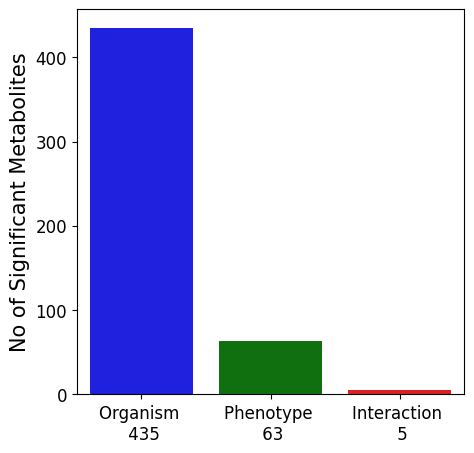

In [15]:
# Define the data
significant_metabolite_data = {
    'Group': ['Organism \n 435', 'Phenotype \n 63', 'Interaction \n 5'],
    'Value': [len(significant_fdr_corrected_pvals_organism), len(significant_fdr_corrected_pvals_group), len(significant_fdr_corrected_pvals_interaction)]
}

# Convert the data into a pandas DataFrame
significant_metabolite_data_df = pd.DataFrame(significant_metabolite_data)

# Create the bar chart
plt.figure(figsize=(5, 5))
sns.barplot(x='Group', y='Value', data=significant_metabolite_data_df, palette=['blue', 'green', 'red'])

# Add title and labels
#plt.title('Bar Chart for 3 Groups', fontsize=14)
plt.xlabel('')
plt.ylabel('No of Significant Metabolites', fontsize=15)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

# Save image
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/boxplot_significant_anova_metabolites.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/boxplot_significant_anova_metabolites.tiff', format='tiff', dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

# Finding significant metabolites between bacteria species 

In [18]:
# Function to perform one-vs-rest OLS regression for multiple dependent variables
def one_vs_rest_ols(data, dependent_vars, group_var):
    unique_groups = data[group_var].unique()
    p_values = {var: [] for var in dependent_vars}

    for group in unique_groups:
        # Create binary indicator for one-vs-rest
        data['group_indicator'] = np.where(data[group_var] == group, 1, 0)

        for var in dependent_vars:
            # Perform OLS regression
            X = sm.add_constant(data['group_indicator'])  # add constant (intercept)
            y = data[var]
            model = sm.OLS(y, X).fit()
            
            # Extract p-value for the group indicator
            p_values[var].append(model.pvalues['group_indicator'])
    
    # Convert to DataFrame for easier handling
    p_values_df = pd.DataFrame(p_values, index=unique_groups)
    
    # Apply FDR correction
    fdr_corrected_pvals = p_values_df.apply(lambda p: multipletests(p, method='fdr_bh')[1])
    
    # Create a final DataFrame with all results
    results = []
    for var in dependent_vars:
        for group in unique_groups:
            results.append({
                'Variable': var,
                'Group': group,
                'P-value': p_values_df.loc[group, var],
                'Adjusted P-value': fdr_corrected_pvals.loc[group, var]
            })
    
    results_df = pd.DataFrame(results)
    
    return results_df

# Apply the function
dependent_vars = annotated_mz_data.drop(columns = ['Group', 'Organism', 'date_measured', 'batch_measured']).columns.tolist()
results_df = one_vs_rest_ols(annotated_mz_data, dependent_vars, group_var='Organism')
results_df

,Variable,Group,P-value,Adjusted P-value
0,341.3045359,Escherichia coli,0.083115,0.166230
1,341.3045359,Enterobacter cloacae,0.045386,0.166230
2,341.3045359,Klebsiella pneumoniae,0.001526,0.012206
3,341.3045359,Klebsiella aerogenes,0.750972,0.775505
4,341.3045359,Citrobacter freundii,0.775505,0.775505
...,...,...,...,...
4091,361.1697371,Klebsiella aerogenes,0.736108,0.841266
4092,361.1697371,Citrobacter freundii,0.010036,0.026761
4093,361.1697371,Serratia marcescens,0.018318,0.029309
4094,361.1697371,Klebsiella oxytoca,0.564427,0.752569


Below we show the number of significant metabolites within each group in the one-vs-rest comparison, as well as the number of significant metabolites found across all groups (it is zero).

In [19]:
# 1. Count the number of adjusted p-values < 0.05 for each group
group_counts = results_df[results_df['Adjusted P-value'] < 0.05].groupby('Group').size()
print("\nCount of Adjusted P-values < 0.05 for Each Group:")
print(group_counts)

# 2. Find variables with adjusted p-values < 0.05 that overlap between all groups
significant_vars = results_df[results_df['Adjusted P-value'] < 0.05]
overlapping_vars = significant_vars.groupby('Variable')['Group'].nunique()
overlapping_vars = overlapping_vars[overlapping_vars == len(results_df['Group'].unique())]

# Filter results_df to include only the overlapping variables
overlapping_results_df = results_df[results_df['Variable'].isin(overlapping_vars.index)]

print("\nOverlapping Variables with Adjusted P-values < 0.05 Across All Groups:")
print(overlapping_results_df)


Count of Adjusted P-values < 0.05 for Each Group:
Group
Citrobacter freundii     172
Enterobacter cloacae     276
Escherichia coli         255
Klebsiella aerogenes      44
Klebsiella oxytoca        56
Klebsiella pneumoniae    347
Proteus mirabilis        142
Serratia marcescens      209
dtype: int64

Overlapping Variables with Adjusted P-values < 0.05 Across All Groups:
Empty DataFrame
Columns: [Variable, Group, P-value, Adjusted P-value]
Index: []


Below we create a bar chart to plot the number of significant metabolites for each species.

C:\Users\nicky\AppData\Local\Temp\ipykernel_26256\586939875.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([r'$\it{' + label.replace(" ", "\ ") + '}$' for label in pd.DataFrame(group_counts).index],


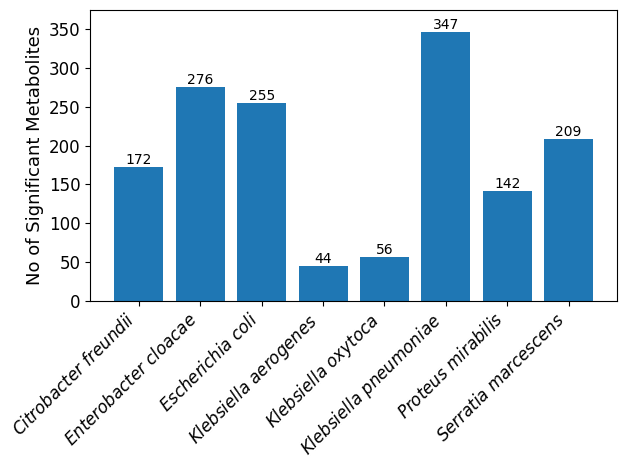

In [20]:
# Create the bar plot
fig, ax = plt.subplots()

# Plot the data (index on x-axis, values on y-axis)
bars = ax.bar(pd.DataFrame(group_counts).index, pd.DataFrame(group_counts)[0])

# Italicize the x-tick labels and ensure multi-word labels remain separate
ax.set_xticklabels([r'$\it{' + label.replace(" ", "\ ") + '}$' for label in pd.DataFrame(group_counts).index], 
                   rotation=45, ha="right", fontsize = 12)
ax.set_ylabel('No of Significant Metabolites', fontsize = 13)
plt.yticks(fontsize = 12)

# Add the frequency text above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')
    
plt.ylim([0, 375])

# Display the plot
plt.tight_layout()
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/bar_chart_species_specific_metabolies.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/bar_chart_species_specific_metabolies.tiff', format='tiff', dpi=300)
plt.show()

## Plotting species vs rest for each species based on all their significant metabolites

Below we plot pca and umaps of the data for the E. Coli data given only the metabolites above and colored by species.

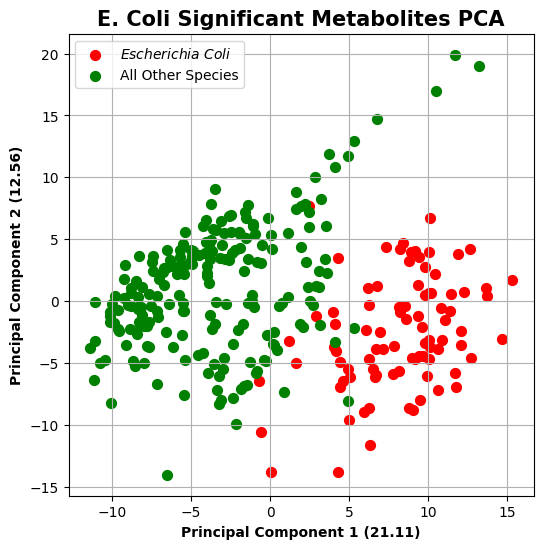

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


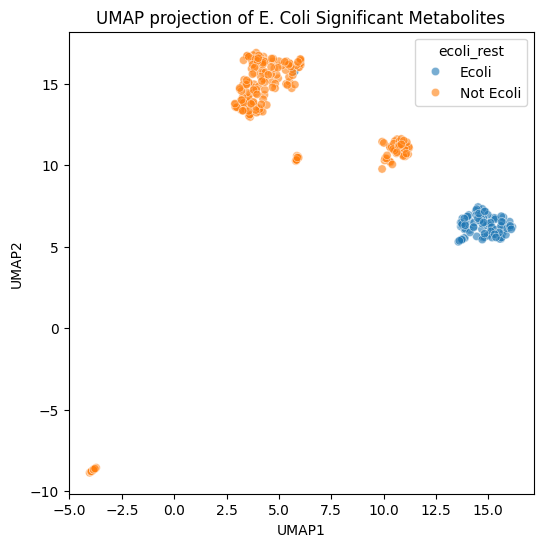

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


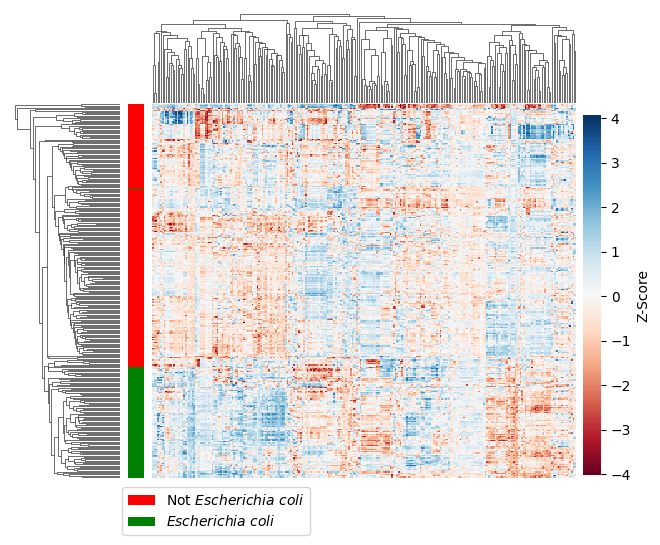

In [21]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['ecoli_rest'] = np.where(annotated_mz_data['Organism'] == 'Escherichia coli', 'Ecoli', 'Not Ecoli')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Escherichia coli') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['ecoli_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('E. Coli Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['Ecoli', 'Not Ecoli']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['ecoli_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Escherichia$ $Coli$', 'All Other Species']
ax.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Escherichia coli') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['ecoli_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='ecoli_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of E. Coli Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_ecoli_organism = pd.Series(annotated_mz_data['ecoli_rest']).map({'Ecoli': 'green', 'Not Ecoli': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Escherichia coli') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_ecoli_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Escherichia\ coli}$'),
                   Patch(facecolor='green', label=r'$\it{Escherichia\ coli}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ecoli_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ecoli_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Enterobacter data given only the metabolites above and colored by species.

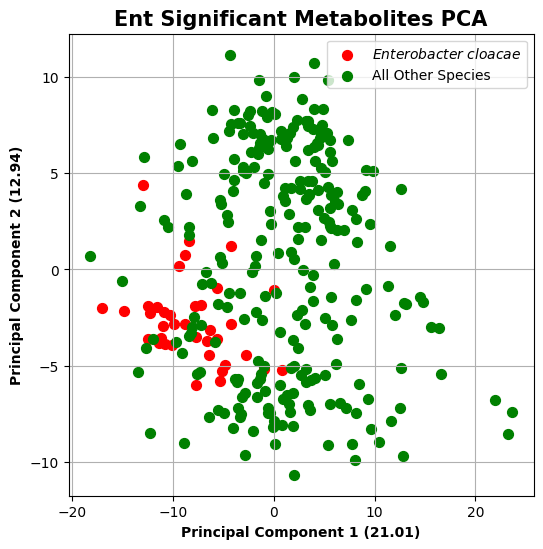

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


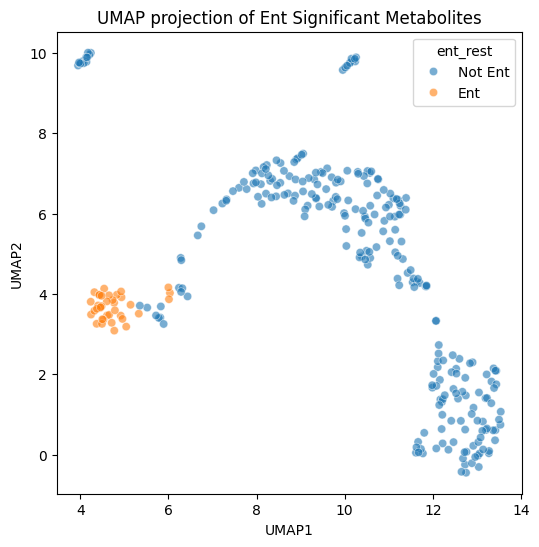

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


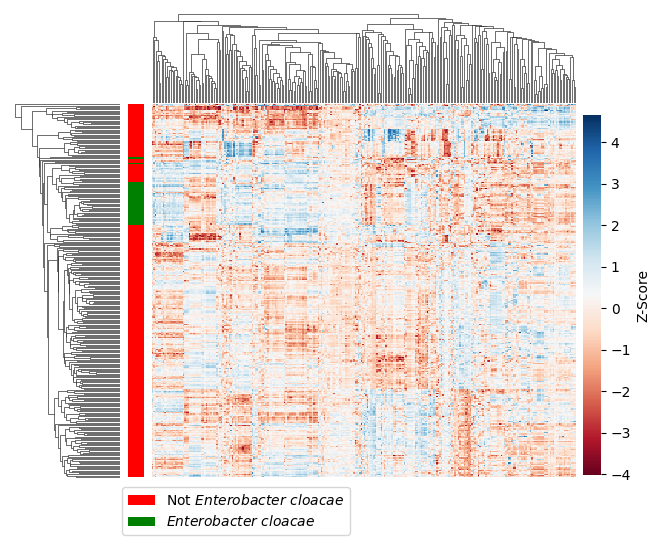

In [22]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['ent_rest'] = np.where(annotated_mz_data['Organism'] == 'Enterobacter cloacae', 'Ent', 'Not Ent')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Enterobacter cloacae') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['ent_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('Ent Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['Ent', 'Not Ent']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['ent_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Enterobacter$ $cloacae$', 'All Other Species']
plt.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Enterobacter cloacae') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['ent_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='ent_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of Ent Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_ent_organism = pd.Series(annotated_mz_data['ent_rest']).map({'Ent': 'green', 'Not Ent': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Enterobacter cloacae') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_ent_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Enterobacter\ cloacae}$'),
                   Patch(facecolor='green', label=r'$\it{Enterobacter\ cloacae}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ent_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ent_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Klebsiella pneumoniae data given only the metabolites above and colored by species.

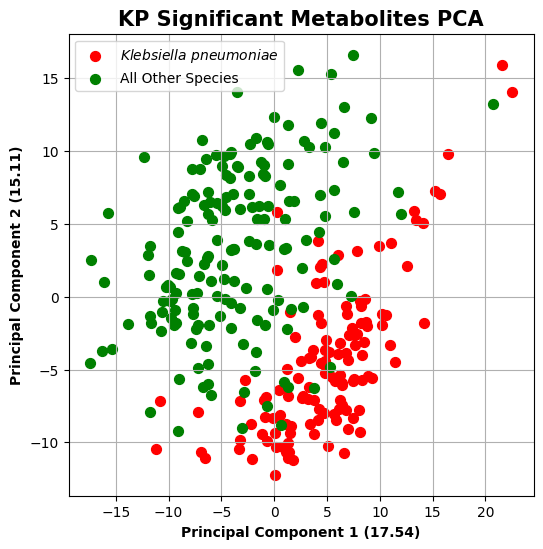

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


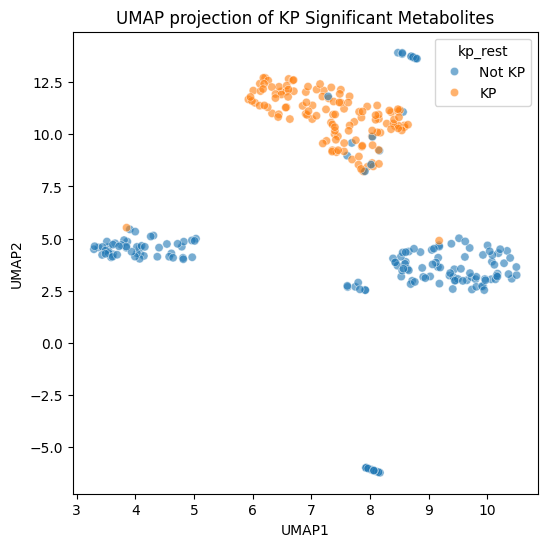

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


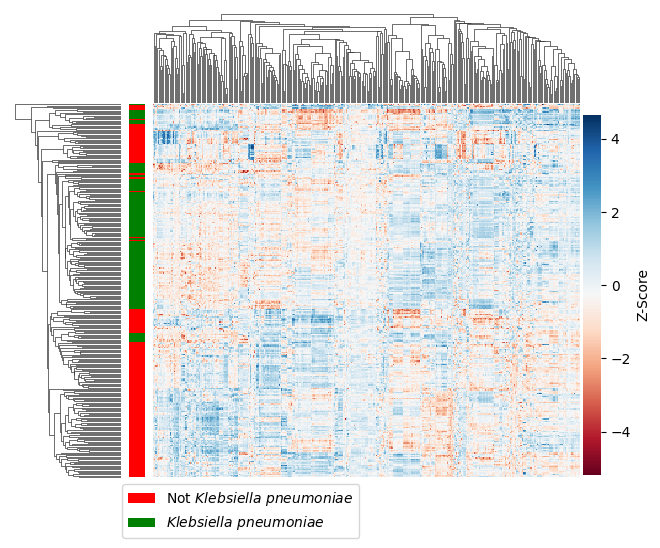

In [23]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['kp_rest'] = np.where(annotated_mz_data['Organism'] == 'Klebsiella pneumoniae', 'KP', 'Not KP')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella pneumoniae') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['kp_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('KP Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['KP', 'Not KP']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['kp_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Klebsiella$ $pneumoniae$', 'All Other Species']
plt.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella pneumoniae') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['kp_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='kp_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of KP Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_kp_organism = pd.Series(annotated_mz_data['kp_rest']).map({'KP': 'green', 'Not KP': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella pneumoniae') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_kp_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Klebsiella\ pneumoniae}$'),
                   Patch(facecolor='green', label=r'$\it{Klebsiella\ pneumoniae}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_kp_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_kp_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Klebsiella aerogenes data given only the metabolites above and colored by species.

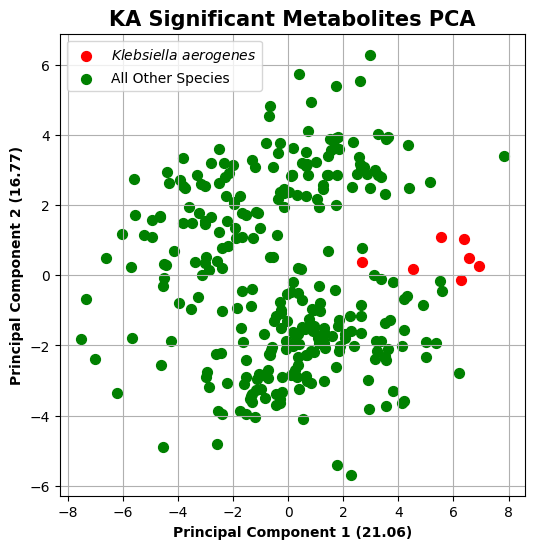

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


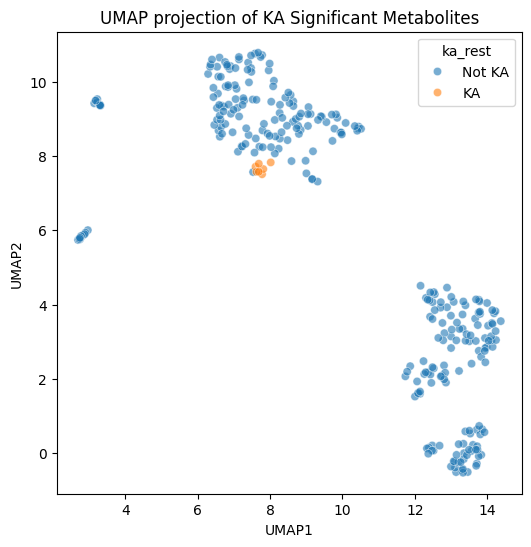

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


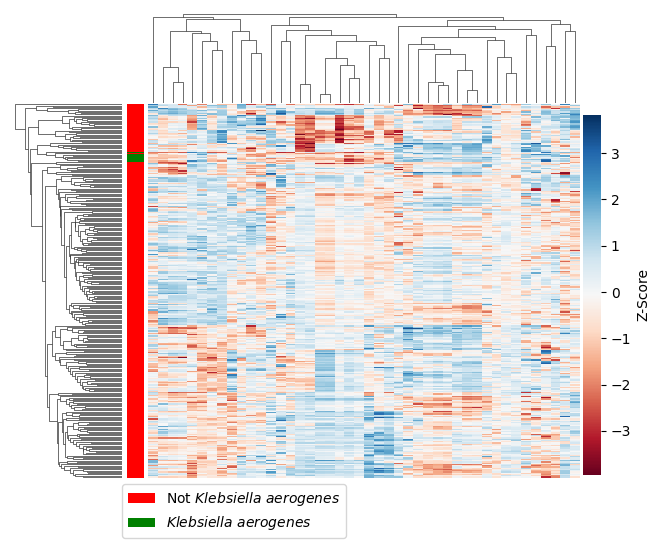

In [24]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['ka_rest'] = np.where(annotated_mz_data['Organism'] == 'Klebsiella aerogenes', 'KA', 'Not KA')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella aerogenes') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['ka_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('KA Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['KA', 'Not KA']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['ka_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Klebsiella$ $aerogenes$', 'All Other Species']
plt.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella aerogenes') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['ka_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='ka_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of KA Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_ka_organism = pd.Series(annotated_mz_data['ka_rest']).map({'KA': 'green', 'Not KA': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella aerogenes') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_ka_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Klebsiella\ aerogenes}$'),
                   Patch(facecolor='green', label=r'$\it{Klebsiella\ aerogenes}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ka_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ka_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Citrobacter freundii data given only the metabolites above and colored by species.

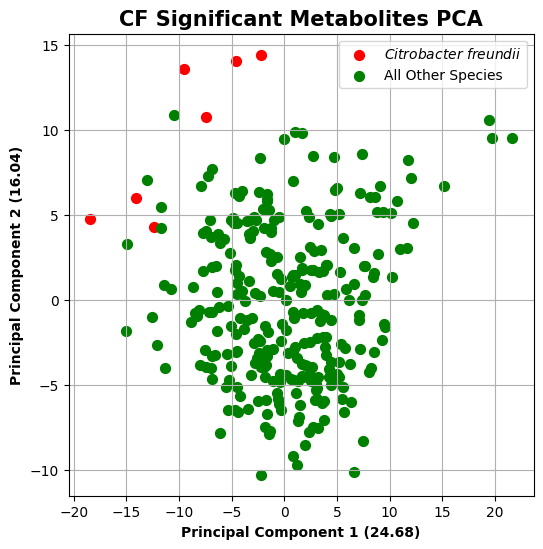

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


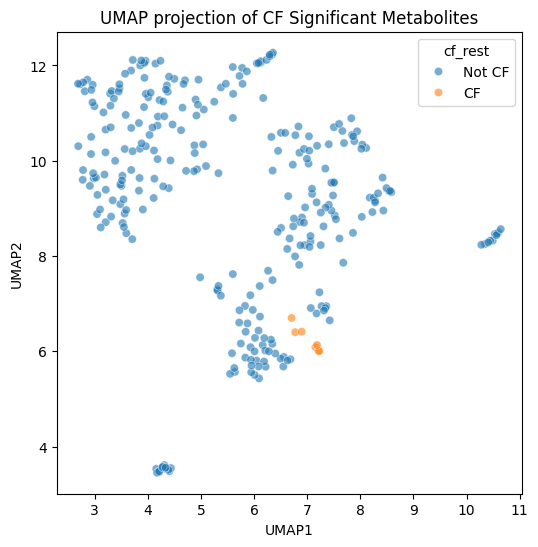

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


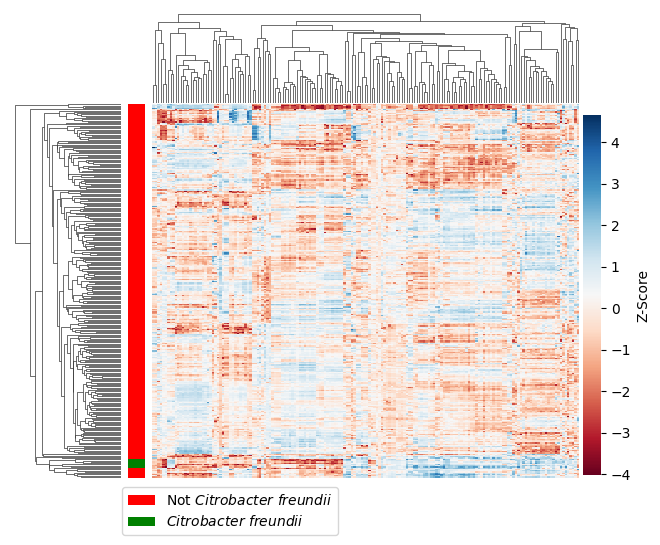

In [25]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['cf_rest'] = np.where(annotated_mz_data['Organism'] == 'Citrobacter freundii', 'CF', 'Not CF')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Citrobacter freundii') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['cf_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('CF Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['CF', 'Not CF']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['cf_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Citrobacter$ $freundii$', 'All Other Species']
ax.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Citrobacter freundii') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['cf_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='cf_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of CF Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_cf_organism = pd.Series(annotated_mz_data['cf_rest']).map({'CF': 'green', 'Not CF': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Citrobacter freundii') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_cf_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Citrobacter\ freundii}$'),
                   Patch(facecolor='green', label=r'$\it{Citrobacter\ freundii}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_cf_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_cf_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Serratia marcescens data given only the metabolites above and colored by species.

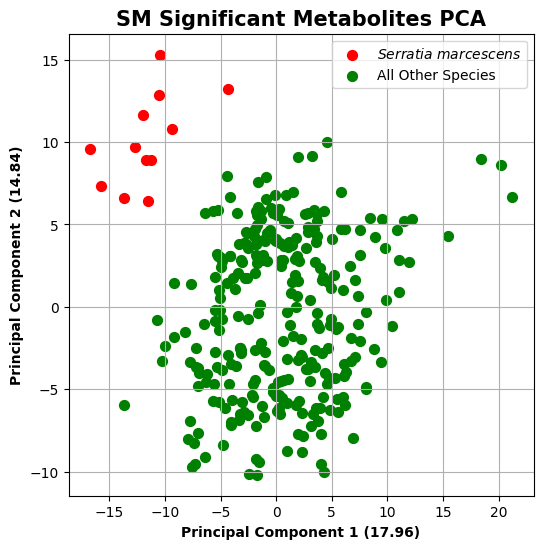

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


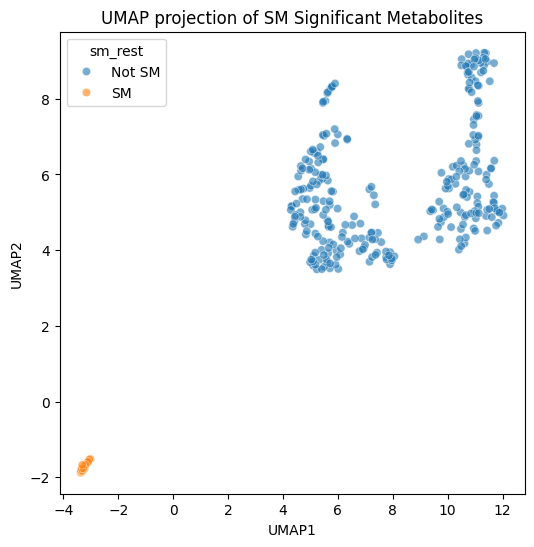

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


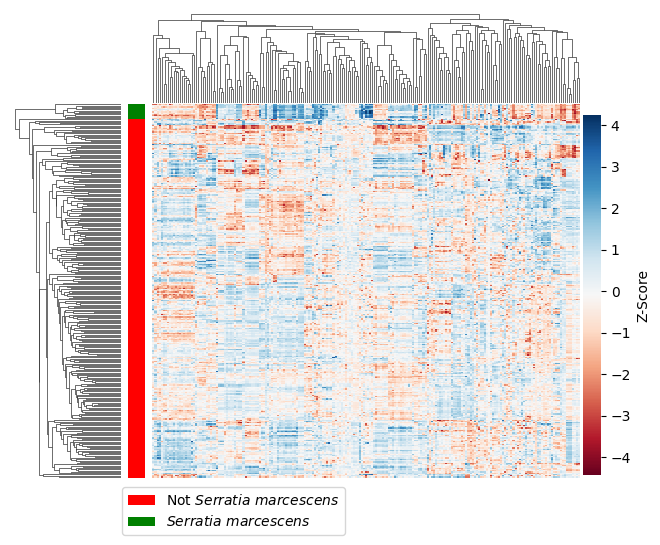

In [26]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['sm_rest'] = np.where(annotated_mz_data['Organism'] == 'Serratia marcescens', 'SM', 'Not SM')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Serratia marcescens') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['sm_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('SM Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['SM', 'Not SM']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['sm_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Serratia$ $marcescens$', 'All Other Species']
ax.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Serratia marcescens') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['sm_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='sm_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of SM Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_sm_organism = pd.Series(annotated_mz_data['sm_rest']).map({'SM': 'green', 'Not SM': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Serratia marcescens') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_sm_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Serratia\ marcescens}$'),
                   Patch(facecolor='green', label=r'$\it{Serratia\ marcescens}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_sm_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_sm_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Proteus mirabilis data given only the metabolites above and colored by species.

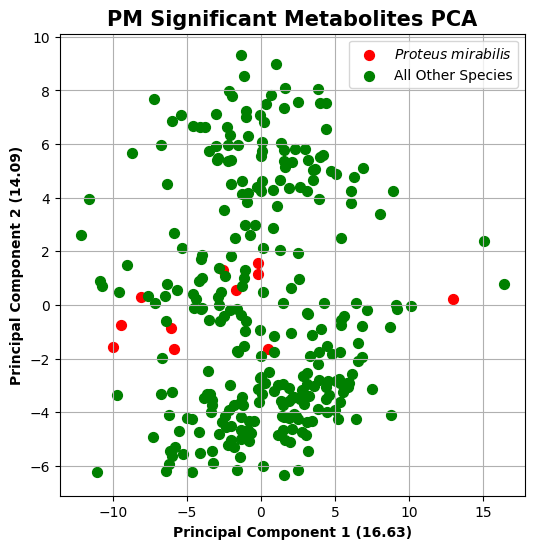

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


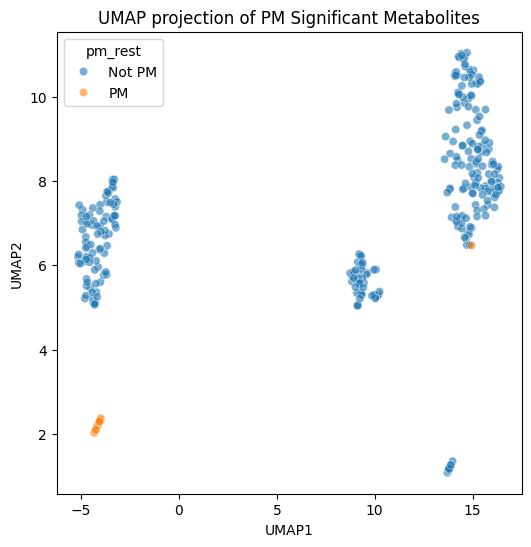

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


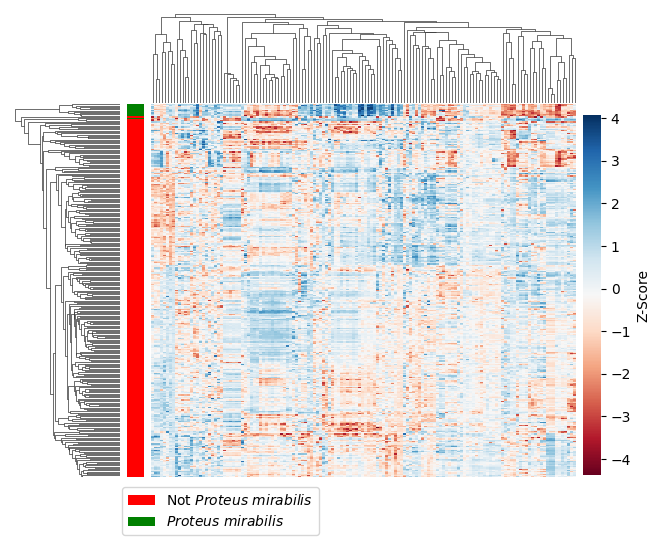

In [27]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['pm_rest'] = np.where(annotated_mz_data['Organism'] == 'Proteus mirabilis', 'PM', 'Not PM')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Proteus mirabilis') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['pm_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('PM Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['PM', 'Not PM']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['pm_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Proteus$ $mirabilis$', 'All Other Species']
ax.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Proteus mirabilis') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['pm_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='pm_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of PM Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_pm_organism = pd.Series(annotated_mz_data['pm_rest']).map({'PM': 'green', 'Not PM': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Proteus mirabilis') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_pm_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Proteus\ mirabilis}$'),
                   Patch(facecolor='green', label=r'$\it{Proteus\ mirabilis}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_pm_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_pm_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")


Below we plot pca and umaps of the data for the Klebsiella oxytoca data given only the metabolites above and colored by species.

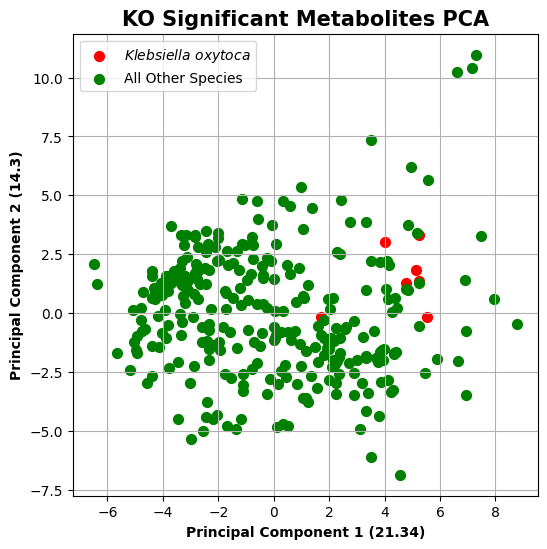

c:\Users\nicky\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


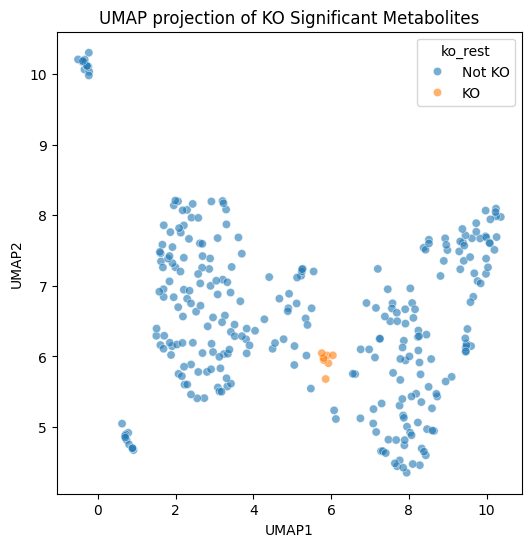

c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nicky\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


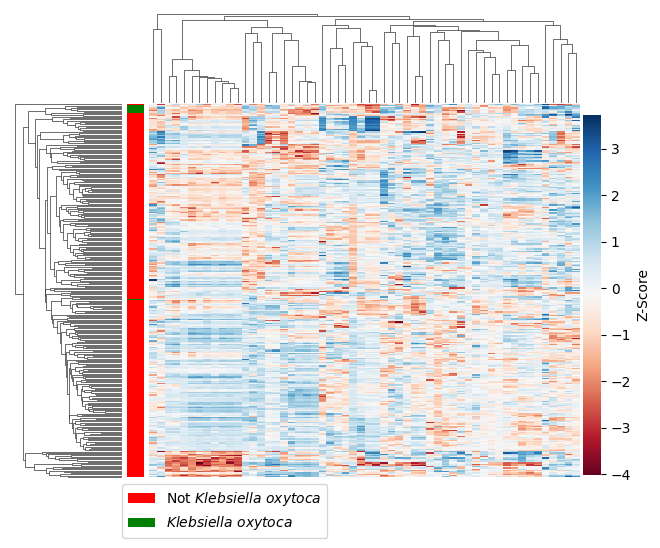

In [28]:
# Create a font property for italicizing
font_italic = FontProperties(style='italic')

# Create binary indicator for one-vs-rest
annotated_mz_data['ko_rest'] = np.where(annotated_mz_data['Organism'] == 'Klebsiella oxytoca', 'KO', 'Not KO')

# Create PCA plot
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella oxytoca') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
percent_variance = np.round(pca.explained_variance_ratio_* 100, decimals =2)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
# Add phenotype info                                  
finalDf = pd.concat([principalDf, annotated_mz_data[['ko_rest']].reset_index()], axis = 1)
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel(f'Principal Component 1 ({percent_variance[0]})', fontsize = 10, fontweight = 'bold')
ax.set_ylabel(f'Principal Component 2 ({percent_variance[1]})', fontsize = 10, fontweight = 'bold')
ax.set_title('KO Significant Metabolites PCA', fontsize = 15, fontweight = 'bold')
labels = ['KO', 'Not KO']
group_numbers = [0, 1]
colors = ['red', 'green']
for group, color in zip(labels,colors):
    indicesToKeep = finalDf['ko_rest'] == group
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 50)
legend_labels = ['$Klebsiella$ $oxytoca$', 'All Other Species']
ax.legend(legend_labels, fontsize = 'medium')
ax.grid()
plt.show()

# UMAP
plt.figure(figsize = (6, 6))
reducer = umap.UMAP(random_state = 100)
embedding = reducer.fit_transform(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella oxytoca') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()])
embedding_df = pd.concat([pd.DataFrame(embedding), annotated_mz_data.reset_index(drop = True)['ko_rest']], axis = 1)
sns.scatterplot(data = embedding_df, hue='ko_rest', x = 0, y = 1, alpha = 0.6)
plt.title('UMAP projection of KO Significant Metabolites', fontsize=12)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## Create a color mapping for the row labels 
row_colors_ko_organism = pd.Series(annotated_mz_data['ko_rest']).map({'KO': 'green', 'Not KO': 'red'})
g = sns.clustermap(annotated_mz_data[results_df[(results_df['Group'] == 'Klebsiella oxytoca') & (results_df['Adjusted P-value'] < 0.05)]['Variable'].tolist()], row_colors = row_colors_ko_organism, metric = 'euclidean', cmap = 'RdBu', figsize = (6, 6), yticklabels=False)
# Set font size for x and y tick labels
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)  # X-axis
# Create a custom legend using matplotlib's Patch
legend_elements = [Patch(facecolor='red', label=r'Not $\it{Klebsiella\ oxytoca}$'),
                   Patch(facecolor='green', label=r'$\it{Klebsiella\ oxytoca}$')]
# Add the legend to the plot
plt.legend(handles=legend_elements, title='', loc='center left', bbox_to_anchor=(-26, -0.1))
# Remove x-axis ticks
g.ax_heatmap.set_xticks([])  # This removes the x-axis ticks from the heatmap
# Remove x-axis labels from the row colors column
g.ax_row_colors.set_xticks([])  # This removes the x-axis labels from the row colors

# Add label to the color bar
g.cax.set_ylabel('Z-Score')  # Label for the scale bar

# Move the colorbar (colormap legend) to a new location
# Adjust the position and size of the colorbar (cax) using `set_position` method
colorbar = g.cax
colorbar.set_position([0.98, 0.2, 0.03, 0.6])  # [left, bottom, width, height] in figure coordinates
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ko_vs_rest.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/clustermap_ko_vs_rest.tiff', format='tiff', dpi=300, bbox_inches="tight")
